In [1]:
import pandas as pd
df = pd.read_excel('./data/apt_seoul.xlsx',skiprows=12, thousands=",")

C:\Users\User\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [2]:
# 불편한 칼럼이름 변경 - 전용면적(㎡)	,거래금액(만원)
# df.rename() 바뀐 복사본 반환 . 원본이 안바뀜
# 1. df = df.rename(....) #복사본을 원본에 저장
# 2. df.rename(...  ,inplace=True) #원본을 수정
df.rename( 
    columns={
        "전용면적(㎡)":"전용면적", 
        "거래금액(만원)":"거래금액"
    }, inplace=True
)

# 시군구를 구,동으로 분리저장
df['구'] = df['시군구'].str.split().str[1]
df['동'] = df['시군구'].str.split().str[2]

# 전용면적 -> 평
df['평'] = df['전용면적'] / 3.3

# 평 -> 평형
def to_ph(x):
    if x < 10: return '10평이하'
    if x < 20: return '10평대'
    if x < 30: return '20평대'
    if x < 40: return '30평대'
    return '40평이상'
df['평형'] = df['평'].apply(to_ph)

# 거래취소된 행 삭제(정상거래된 행)
df = df.query(' 해제사유발생일 == "-" ')

# 가격에 영향없는 칼럼 삭제
df.drop(columns=['NO', '번지', '본번', '부번','매수자', '매도자', '도로명', '해제사유발생일', '거래유형', '중개사소재지',
       '등기일자', '주택유형',], inplace=True)

# 거래금액을 억단위로 변환
df['거래금액'] = df['거래금액'] / 10000

# 계약년월+계약일 -> 요일
df['계약일자'] = pd.to_datetime(
    df['계약년월'].astype(str) + df['계약일'].astype(str).str.zfill(2),
    format='%Y%m%d'
)

df['계약요일'] = df['계약일자'].dt.day_name().map({
    'Monday': '월', 'Tuesday': '화', 'Wednesday': '수',
    'Thursday': '목', 'Friday': '금', 'Saturday': '토', 'Sunday': '일'
})

### 위 아파트 데이터 로딩후 전처리한 결과를 바탕으로 아래 문제를 풀어보세요
### 위 코드를 먼저 실행하세요

## 🟢 기본 탐색

1. 데이터의 행과 열의 개수를 구하시오.

In [3]:
df.shape

(71669, 14)

2. 각 컬럼의 데이터 타입을 확인하시오.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71669 entries, 0 to 76665
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   시군구     71669 non-null  object        
 1   단지명     71669 non-null  object        
 2   전용면적    71669 non-null  float64       
 3   계약년월    71669 non-null  int64         
 4   계약일     71669 non-null  int64         
 5   거래금액    71669 non-null  float64       
 6   동       71669 non-null  object        
 7   층       71669 non-null  int64         
 8   건축년도    71669 non-null  int64         
 9   구       71669 non-null  object        
 10  평       71669 non-null  float64       
 11  평형      71669 non-null  object        
 12  계약일자    71669 non-null  datetime64[ns]
 13  계약요일    71669 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(6)
memory usage: 8.2+ MB


3. 수치형 데이터의 기초 통계량과 문자형 데이터의 기초통계량을 구하시오.

In [5]:
# 수치형 데이터
df.describe(include='number')

,전용면적,계약년월,계약일,거래금액,층,건축년도,평
count,71669.00000,71669.000000,71669.000000,71669.000000,71669.000000,71669.000000,71669.000000
mean,75.21771,202527.183343,16.408029,11.944678,9.562977,2003.209923,22.793246
std,27.33249,38.121455,8.505771,8.788101,6.358990,11.287104,8.282573
min,12.01000,202504.000000,1.000000,0.650000,-2.000000,1961.000000,3.639394
25%,59.74790,202506.000000,10.000000,6.780000,5.000000,1996.000000,18.105424
50%,79.94500,202509.000000,17.000000,9.800000,9.000000,2003.000000,24.225758
75%,84.96000,202512.000000,24.000000,14.550000,13.000000,2012.000000,25.745455
max,317.36000,202604.000000,31.000000,290.000000,66.000000,2025.000000,96.169697


In [6]:
# 문자형 데이터
df.describe(include='object')

,시군구,단지명,동,구,평형,계약요일
count,71669,71669,71669,71669,71669,71669
unique,320,4894,318,25,5,7
top,서울특별시 노원구 상계동,현대,상계동,노원구,20평대,토
freq,2411,713,2411,6153,30229,16718


4. 각 칼럼별 결측치갯수를 출력하시오.

In [7]:
df.isna().sum()

시군구     0
단지명     0
전용면적    0
계약년월    0
계약일     0
거래금액    0
동       0
층       0
건축년도    0
구       0
평       0
평형      0
계약일자    0
계약요일    0
dtype: int64

## 🟡 단일 변수 분석

5. 전체 거래금액의 평균, 최대값, 최소값을 구하시오. 

In [8]:
df['거래금액'].agg(['mean','max','min'])

mean     11.944678
max     290.000000
min       0.650000
Name: 거래금액, dtype: float64

6. 각 구별 거래 건수를 구하시오.

<Axes: xlabel='구'>

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54252 (\N{HANGUL SY

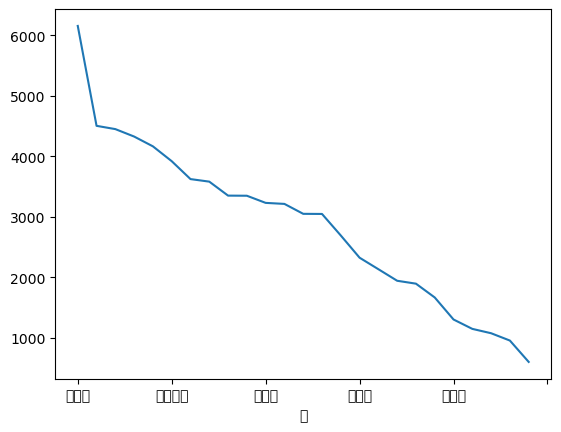

In [9]:
df['구'].value_counts() #자동 정렬, 추천
df.groupby('구')['구'].count().sort_values() #오름차순
df.groupby('구')['구'].count().sort_values(ascending=False) #내림차순

#바 그래프로
# df['구'].value_counts().plot.bar() #막대
# df['구'].value_counts().plot.barh() #막대수평
df['구'].value_counts().plot.line() #선그래프


7. 평형별 거래 건수를 구하시오.

In [10]:
#위와 동일
df.groupby('평형')['구'].count()
# df['평형'].value_counts #빈도수

평형
10평대     28556
10평이하     3171
20평대     30229
30평대      7219
40평이상     2494
Name: 구, dtype: int64

8. 층의 분포를 시각화하시오.

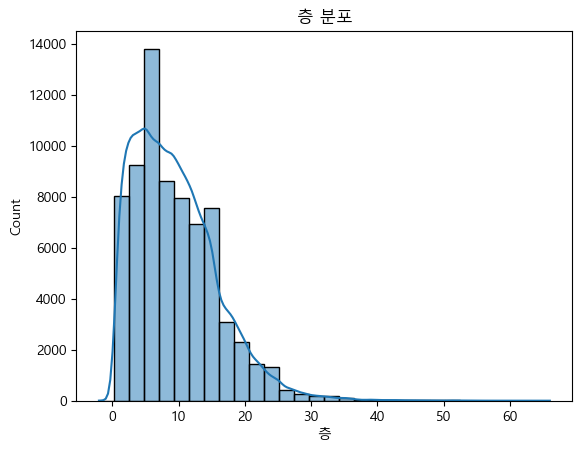

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font',family='Malgun Gothic')
sns.histplot(df['층'], bins=30, kde=True)
plt.title('층 분포')
plt.show()

## 🟠 그룹 분석

9. 구별 거래금액의 평균, 최대값, 최소값을 구하시오.  


In [12]:
df.groupby('구')['거래금액'].agg(['mean','max','min']).sort_values('mean', ascending=False)

,mean,max,min
구,,,
강남구,28.351920,190.00,1.3500
서초구,25.226896,96.00,1.9800
용산구,20.111613,167.00,1.5000
송파구,18.683833,67.00,1.5000
성동구,16.326495,290.00,1.3000
마포구,14.777156,40.00,1.0000
광진구,14.191279,39.00,1.1500
양천구,13.296219,43.50,1.2000
동작구,13.177472,35.00,1.1000


In [13]:
df.query('거래금액 == 290')

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일
60199,서울특별시 성동구 성수동1가,아크로서울포레스트,273.928,202506,11,290.0,성수동1가,47,2020,성동구,83.008485,40평이상,2025-06-11,수


10.    계절별 거래금액의 평균, 최대값, 최소값을 구하시오.  

In [14]:
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['계절'] = df['계약일자'].dt.month.apply(get_season)
df.groupby('계절')['거래금액'].agg(['mean','max','min'])
# df.groupby('계절')['층'].count()

,mean,max,min
계절,,,
가을,12.494941,127.7,0.650
겨울,11.244194,155.0,0.700
봄,11.116617,187.0,0.695
여름,12.586548,290.0,0.700


11. 구별 평형별 평균 거래금액을 구하시오.

<Axes: ylabel='구,평형'>

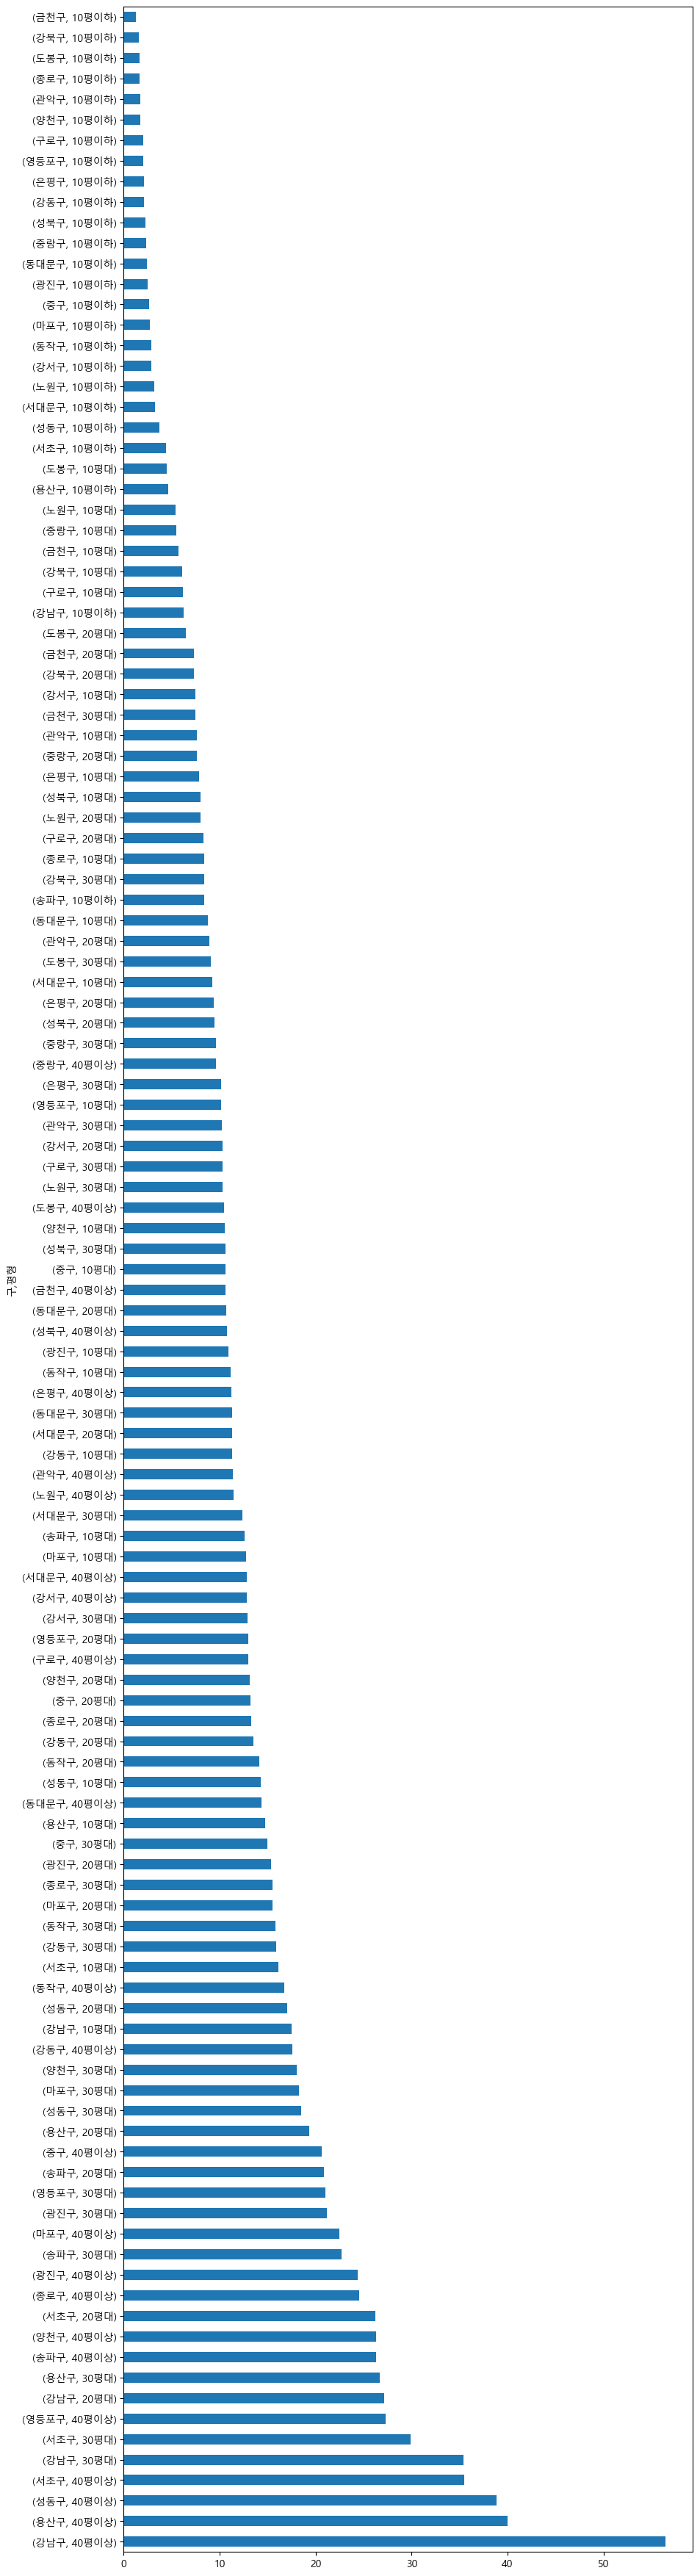

In [15]:
#행 갯수제한 해제
import pandas as pd
pd.set_option('display.max_rows', None) #다나옴
# pd.set_option('display.max_cols', None) #칼럼

#재한 해제 리셋
# pd.reset_option('display.max_rows', None)
# pd.reset_option('display.max_cols', None)


# df.groupby(['구','평형'])['거래금액'].mean()
df.groupby(['구','평형'])['거래금액'].mean()\
  .sort_values(ascending=False)\
  .plot.barh(figsize=(10,45))

## 🔵 시각화

12. 구별 평균 거래금액을 막대그래프로 표현하시오.

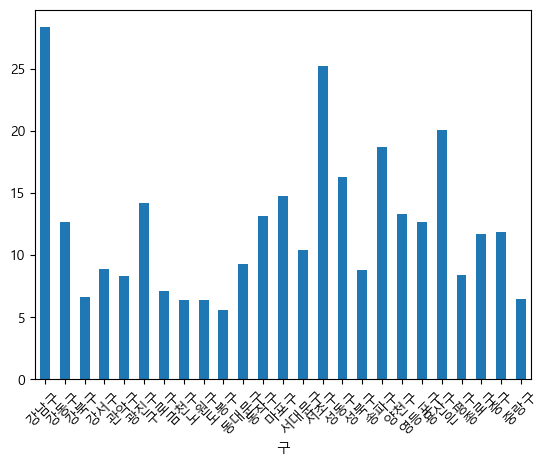

In [16]:
df.groupby('구')['거래금액'].mean().plot.bar(rot=45)
plt.show()

13. 전용면적과 거래금액의 관계를 산점도로 표현하시오.

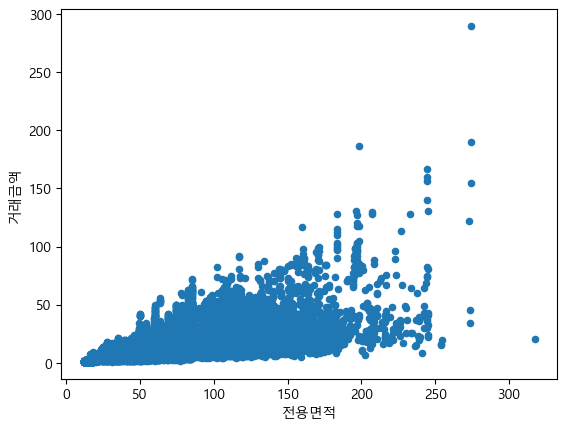

In [17]:
df.plot.scatter(x='전용면적', y='거래금액')
plt.show()

14. 평형별 거래금액 분포를 박스플롯으로 표현하시오.

<Axes: xlabel='평형', ylabel='거래금액'>

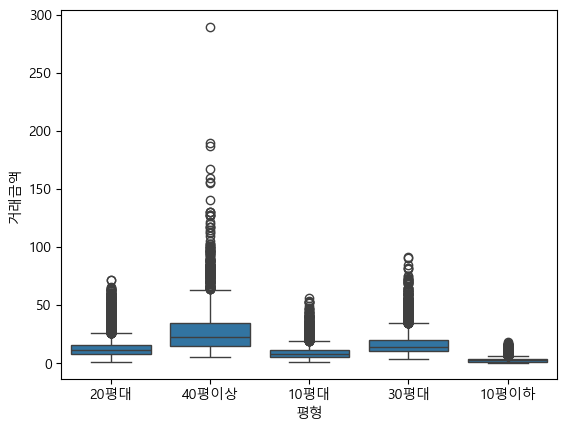

In [18]:
import seaborn as sns
sns.boxplot(data=df, x='평형', y='거래금액')

## 🔴 시간 분석

15. 요일별 거래 건수를 구하시오.

<Axes: xlabel='계약요일'>

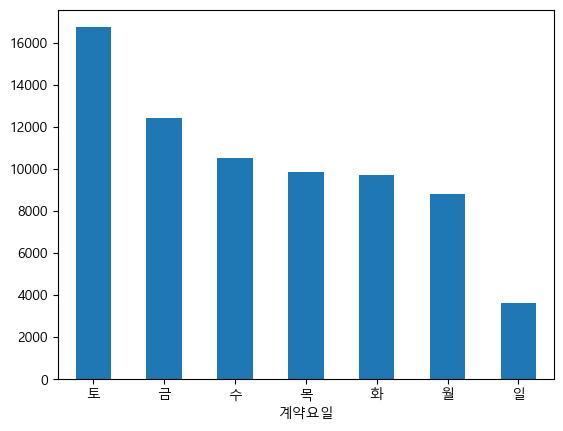

In [19]:
# df.groupby('계약요일')['층'].count()
# df['계약요일'].value_counts()
df['계약요일'].value_counts().plot.bar(rot=0)

16. 요일별 평균 거래금액을 구하시오.

<Axes: xlabel='계약요일'>

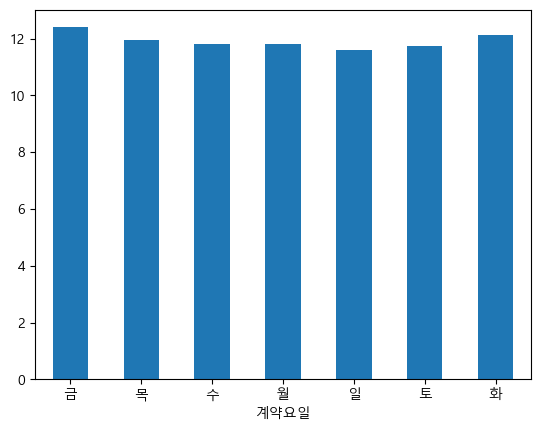

In [20]:
df.groupby('계약요일')['거래금액'].mean()
df.groupby('계약요일')['거래금액'].mean().plot.bar(rot=0)

17. 날짜별 거래 건수 추이를 확인하시오.

계약일자
2025-04-07     147
2025-04-08     162
2025-04-09     131
2025-04-10     157
2025-04-11     189
2025-04-12     281
2025-04-13      70
2025-04-14     195
2025-04-15     149
2025-04-16     163
2025-04-17     157
2025-04-18     183
2025-04-19     362
2025-04-20      60
2025-04-21     145
2025-04-22     166
2025-04-23     157
2025-04-24     139
2025-04-25     173
2025-04-26     367
2025-04-27      78
2025-04-28     179
2025-04-29     189
2025-04-30     291
2025-05-01     314
2025-05-02     193
2025-05-03     245
2025-05-04      31
2025-05-05      70
2025-05-06     134
2025-05-07     190
2025-05-08     187
2025-05-09     242
2025-05-10     433
2025-05-11      95
2025-05-12     197
2025-05-13     200
2025-05-14     186
2025-05-15     220
2025-05-16     230
2025-05-17     442
2025-05-18      90
2025-05-19     213
2025-05-20     223
2025-05-21     209
2025-05-22     219
2025-05-23     291
2025-05-24     520
2025-05-25      90
2025-05-26     229
2025-05-27     251
2025-05-28     268
2025-05

<Axes: ylabel='계약일자'>

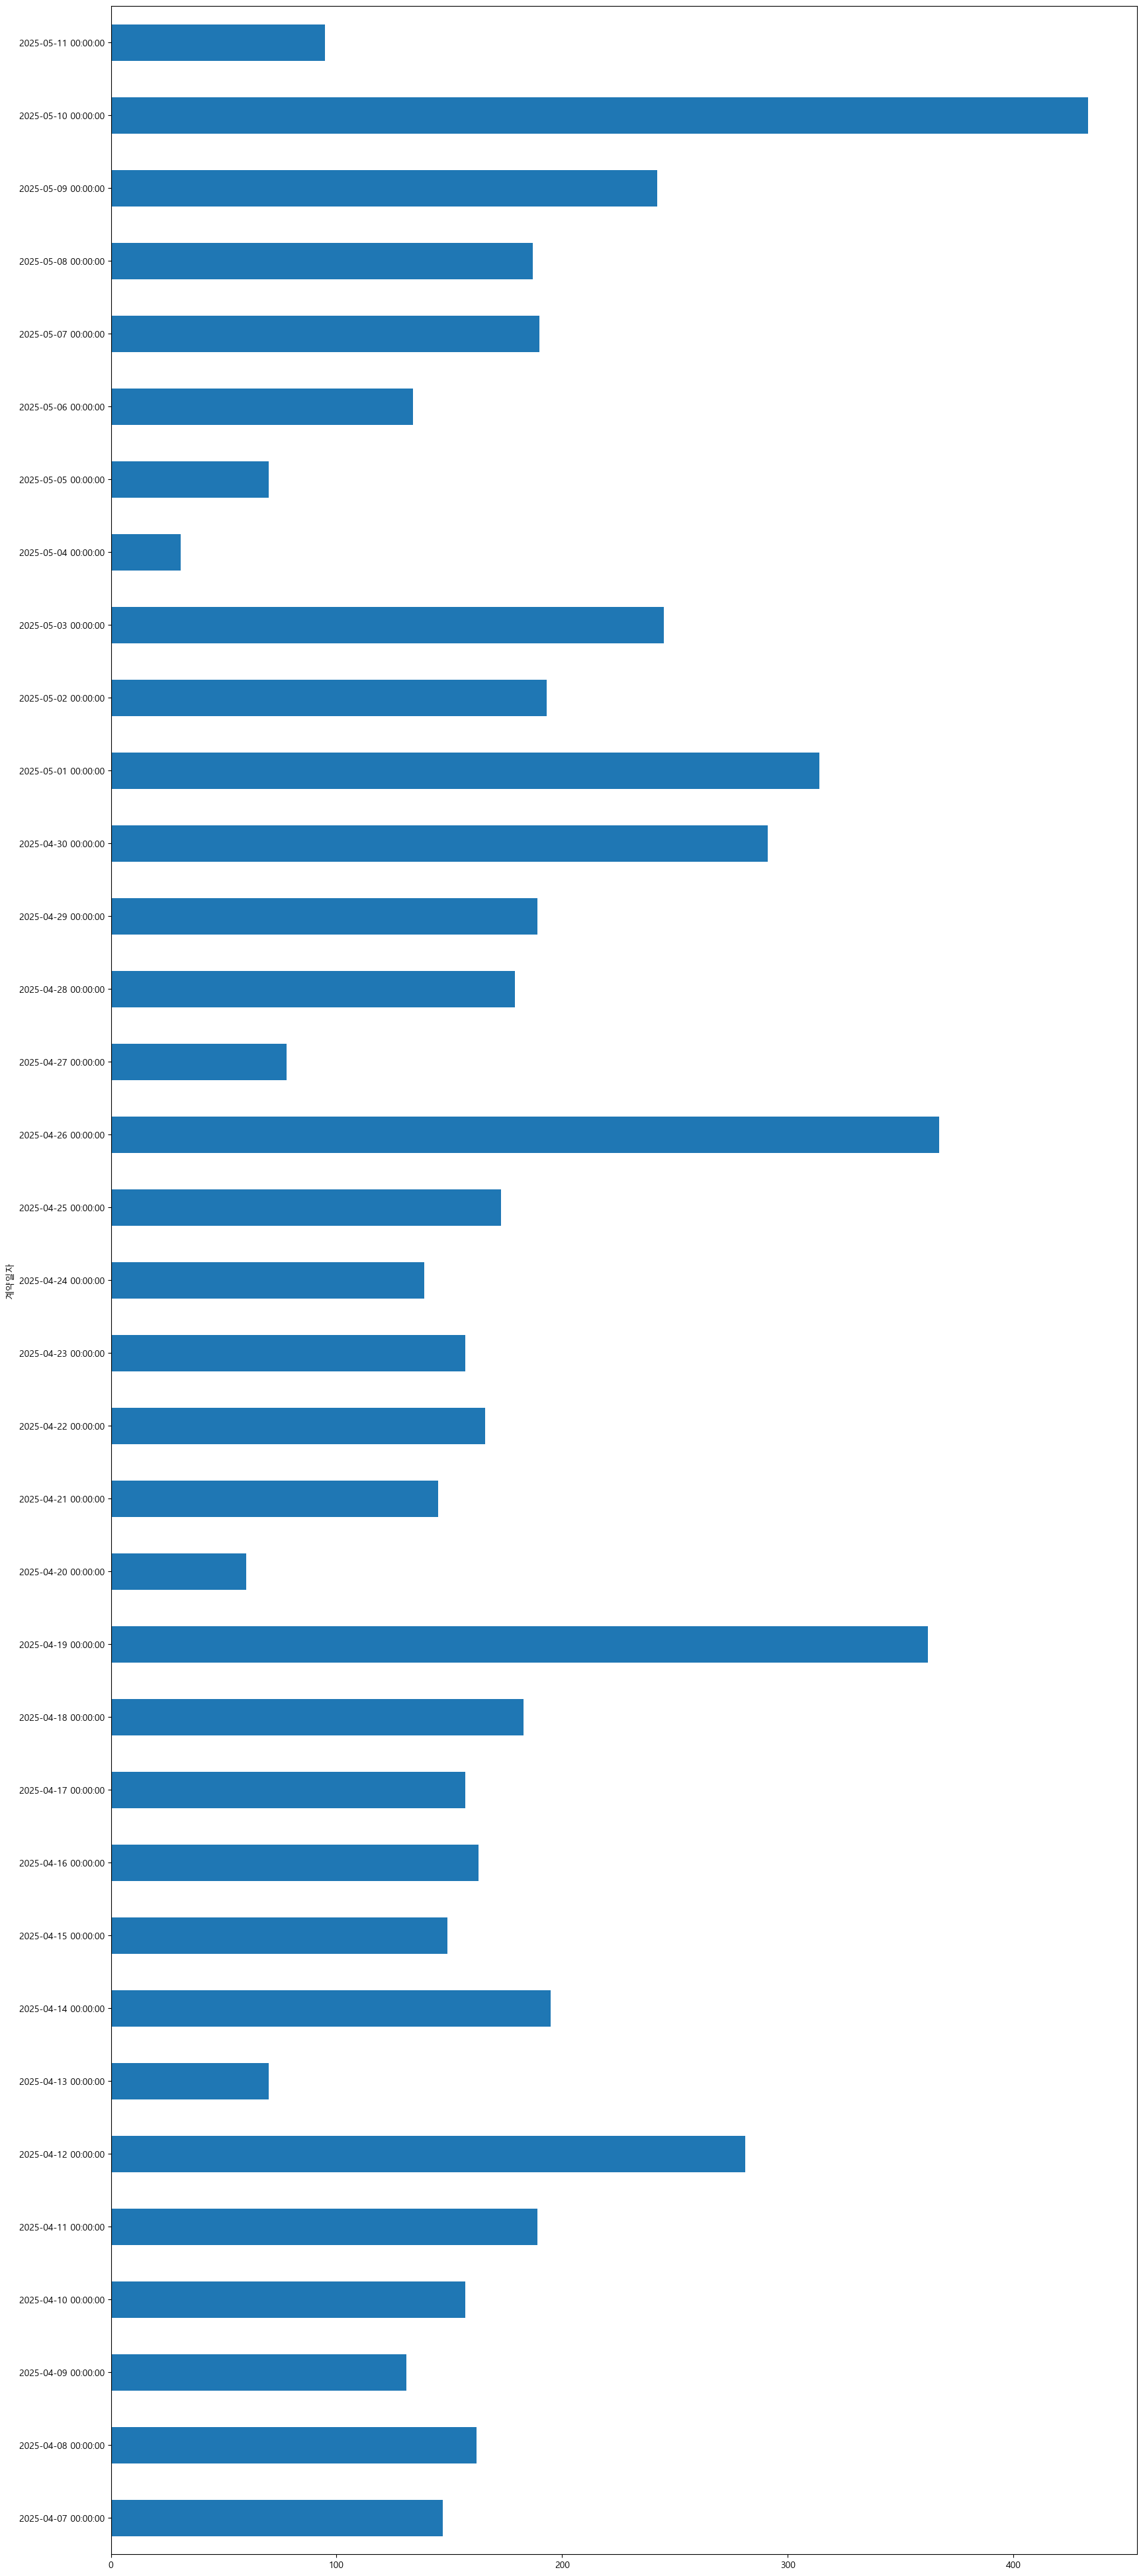

In [21]:
# import matplotlib.pyplot as plt

# # 날짜별 거래건수 집계
# daily_count = df.groupby('계약일자').size()

# # 시계열 그래프
# plt.figure(figsize=(15,5))
# daily_count.plot()
# plt.title('날짜별 거래건수 추이')
# plt.xlabel('계약일자')
# plt.ylabel('거래건수')
# plt.show()

print(df.groupby('계약일자').size().sort_index())
df.groupby('계약일자').size().sort_index().head(35).plot.barh(figsize=(20,50))

C:\Users\User\AppData\Local\Temp\ipykernel_5296\191030687.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_count = df.resample('M', on='계약일자').size()


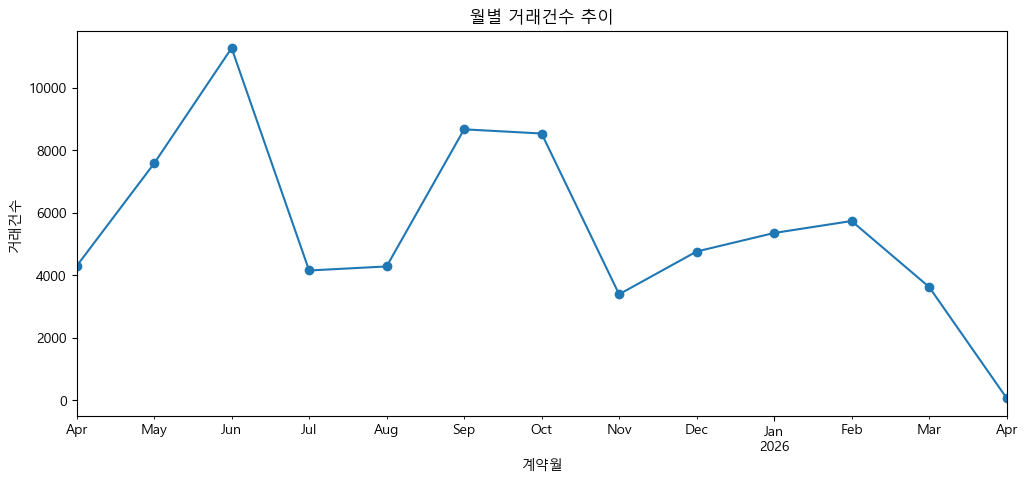

In [22]:
monthly_count = df.resample('M', on='계약일자').size()

plt.figure(figsize=(12,5))
monthly_count.plot(marker='o')
plt.title('월별 거래건수 추이')
plt.xlabel('계약월')
plt.ylabel('거래건수')
plt.show()

## 🟣 심화 분석

18. 거래 건수가 가장 많은 구 TOP 5를 구하시오.

In [23]:
df['구'].value_counts().head(5)

구
노원구    6153
강동구    4502
강서구    4448
성북구    4325
송파구    4163
Name: count, dtype: int64

19. 거래금액이 가장 높은 상위 10건을 조회하시오.

In [24]:
df.sort_values(by='거래금액', ascending=False).head(10)

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일,계절
60199,서울특별시 성동구 성수동1가,아크로서울포레스트,273.9280,202506,11,290.0,성수동1가,47,2020,성동구,83.008485,40평이상,2025-06-11,수,여름
50587,서울특별시 강남구 청담동,PH129,273.9600,202507,1,190.0,청담동,12,2020,강남구,83.018182,40평이상,2025-07-01,화,여름
64311,서울특별시 성동구 성수동1가,아크로서울포레스트,198.2190,202505,29,187.0,성수동1가,46,2020,성동구,60.066364,40평이상,2025-05-29,목,봄
45639,서울특별시 용산구 한남동,나인원한남,244.3478,202508,5,167.0,한남동,5,2019,용산구,74.044788,40평이상,2025-08-05,화,여름
45341,서울특별시 용산구 한남동,나인원한남,244.3478,202508,8,160.0,한남동,4,2019,용산구,74.044788,40평이상,2025-08-08,금,여름
707,서울특별시 용산구 한남동,나인원한남,244.3478,202603,23,156.5,한남동,4,2019,용산구,74.044788,40평이상,2026-03-23,월,봄
18149,서울특별시 강남구 청담동,PH129,273.9600,202512,12,155.0,청담동,10,2020,강남구,83.018182,40평이상,2025-12-12,금,겨울
13518,서울특별시 용산구 한남동,나인원한남,244.3478,202601,12,140.4,한남동,5,2019,용산구,74.044788,40평이상,2026-01-12,월,겨울
43995,서울특별시 강남구 압구정동,"현대1차(12,13,21,22,31,32,33동)",196.2100,202508,18,130.5,압구정동,6,1976,강남구,59.457576,40평이상,2025-08-18,월,여름
73255,서울특별시 강남구 압구정동,"현대7차(73~77,82,85동)",245.2000,202504,25,130.5,압구정동,8,1979,강남구,74.303030,40평이상,2025-04-25,금,봄


20. 강남3구+용산구와 그외지역의 거래건수,평균거래가격 를 출력하세요.

In [25]:
g3y = ['강남구', '서초구', '송파구', '용산구']

df['지역구분'] = df['구'].apply(lambda x: '핵심지역' if x in g3y else '그외지역')

summary = df.groupby('지역구분')['거래금액'].agg(['count', 'mean'])
# summary.rename(columns={'count':'거래건수', 'mean':'평균거래금액'}, inplace=True)
print(summary)

      count       mean
지역구분                  
그외지역  61775  10.217206
핵심지역   9894  22.730465


### 3년전에 비해 가장 가격이 많이 오른 구는? 아파트는? 평형은?

1. 데이터 수집 (국토부 실거래가)
2. 전처리 (이전데이터와 동일)
3. 데이터 합치기 (옵션)
4. 원하는 값 추출, 결과 생성

In [26]:
df.head(1)

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일,계절,지역구분
0,서울특별시 은평구 수색동,DMC 진흥,78.2853,202604,4,7.75,수색동,15,2003,은평구,23.722818,20평대,2026-04-04,토,봄,그외지역
